Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252
Running inference on the test set...
Correct counts per class: {'Dysfunctional': 511}
Misclassified counts per class: {'Dysfunctional': 1996}

Sampling 5 correct examples per class...

Sampling 5 misclassified examples per class...

Total images to plot: 10

CORRECTLY CLASSIFIED EXAMPLES (5 per class)


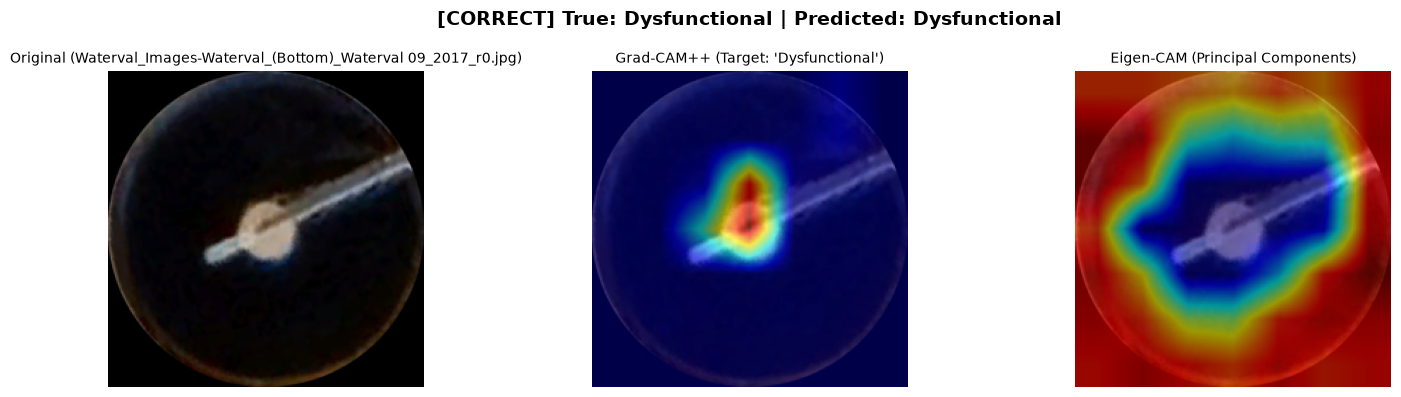

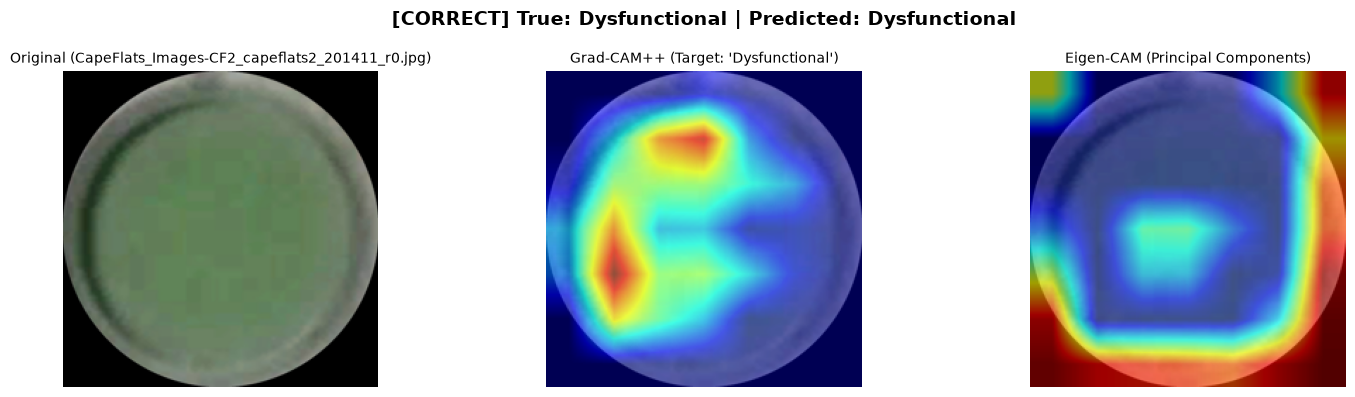

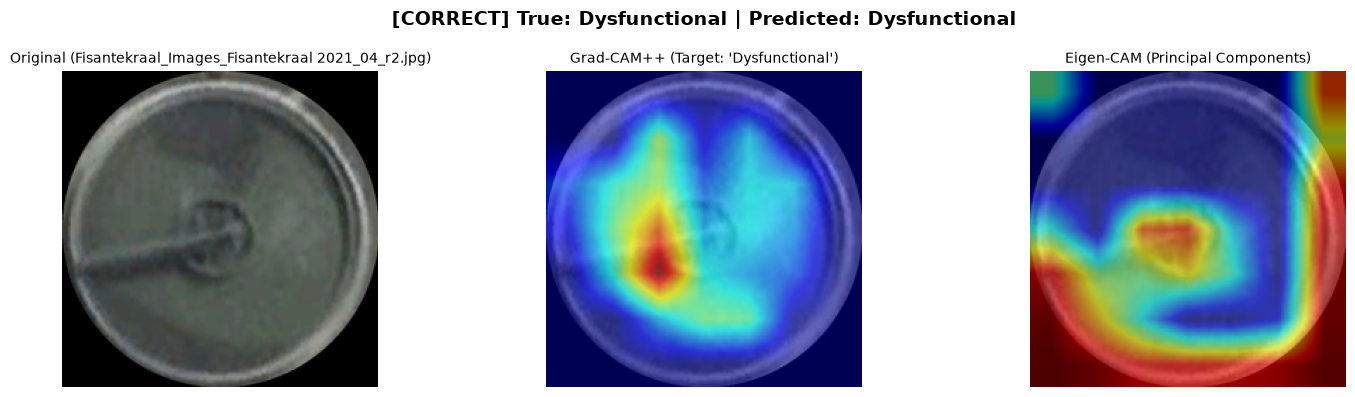

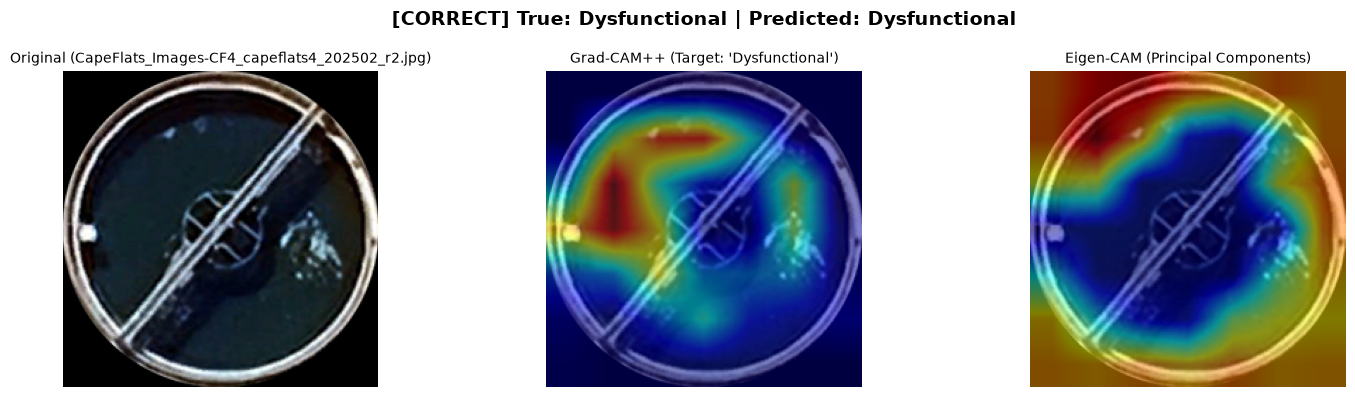

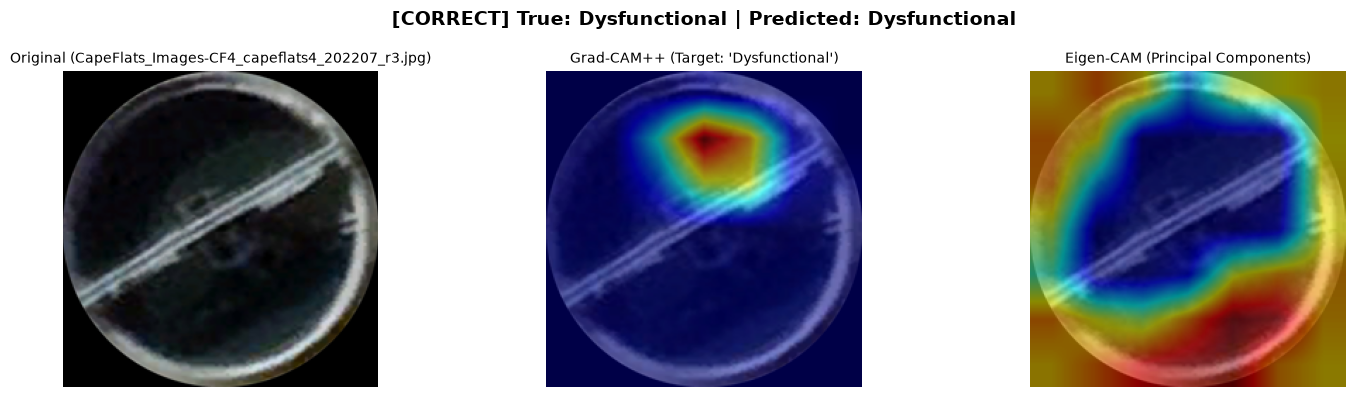


MISCLASSIFIED EXAMPLES (5 per class)


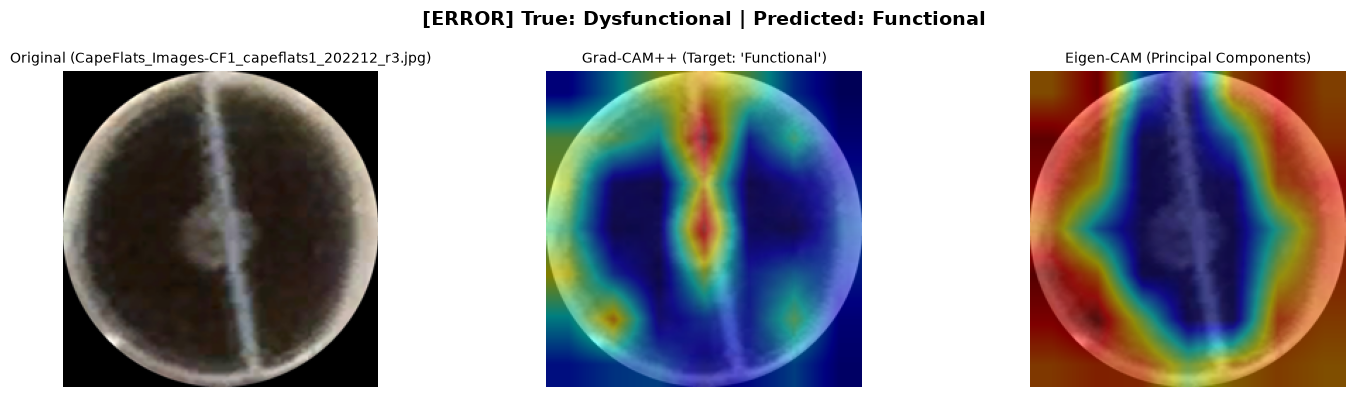

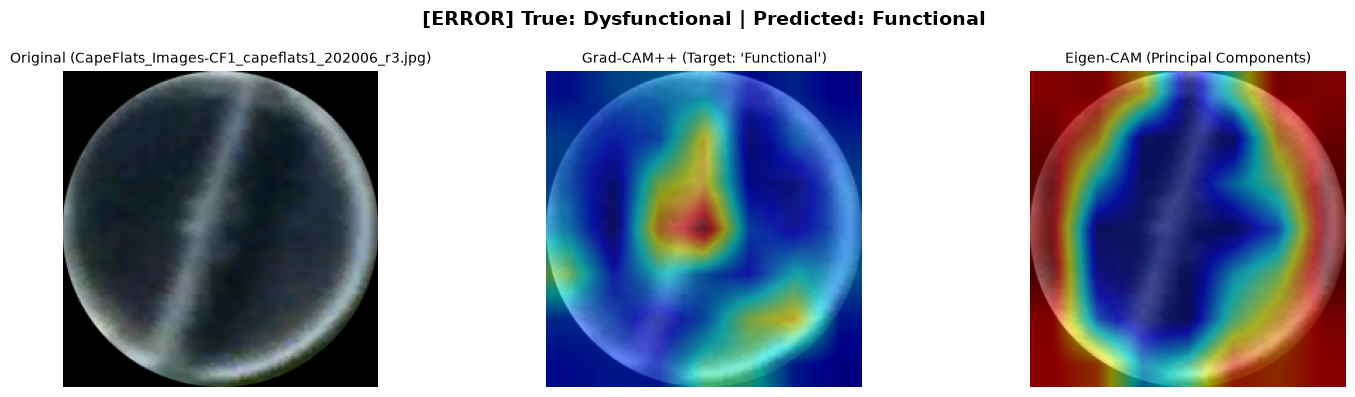

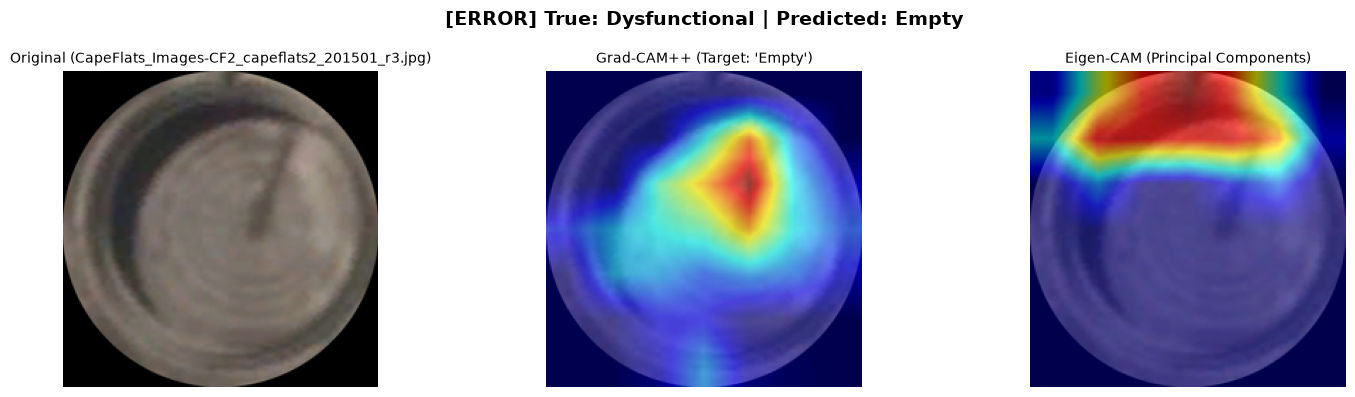

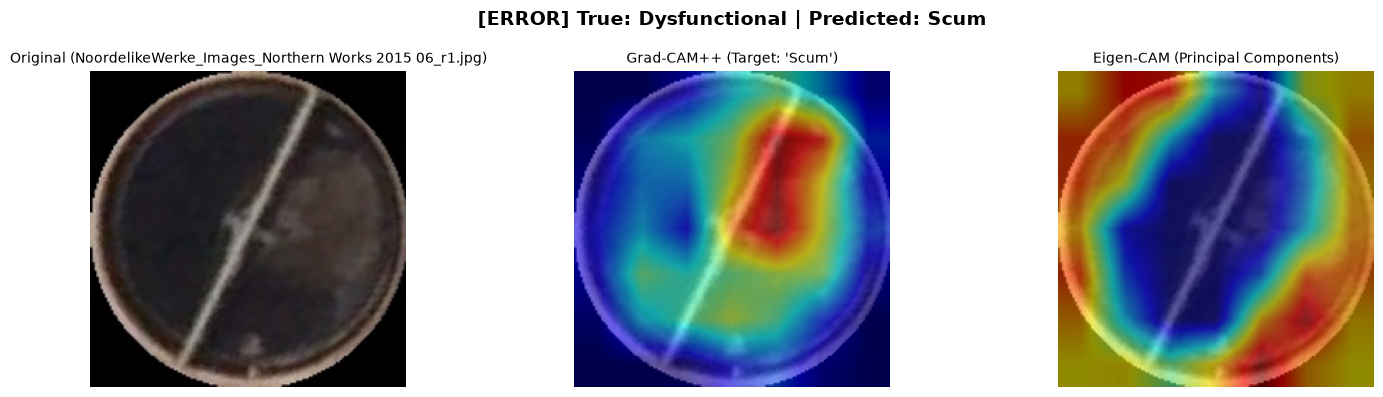

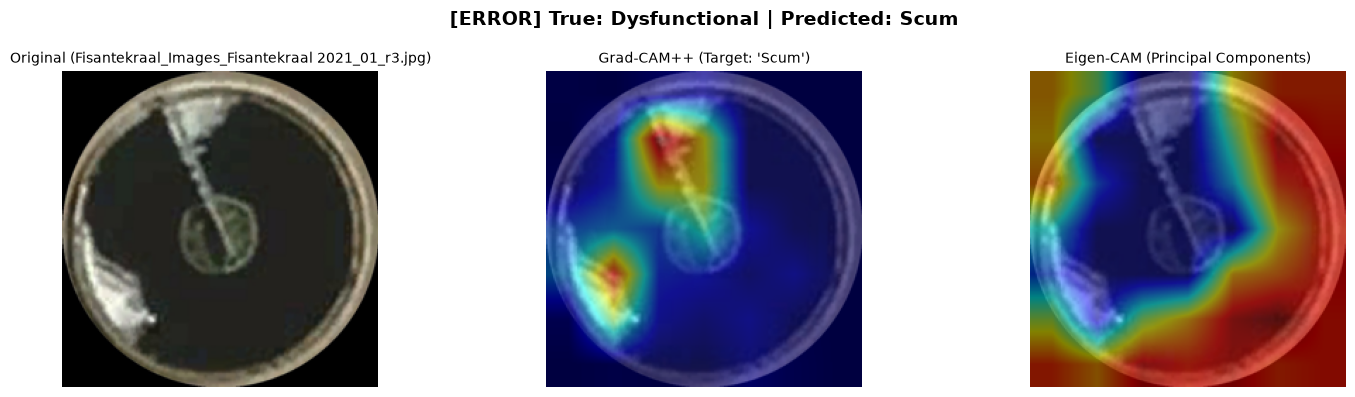

In [1]:
import random
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import models, transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

from pytorch_grad_cam import GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from wwtw_utils import build_classifier_head

# --- 1. Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COMPONENT = "clarifier"

TEST_DIR = Path("../cnn_dataset_split_facility_test-Fisantekraal")
MODEL_WEIGHTS = Path(f"../models/{COMPONENT}_convnext_tiny_cnn.pt")

IMG_SIZE = (224, 224)
SAMPLES_PER_CLASS = 5
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

# --- 2. Reconstruct Model & Load Weights ---
checkpoint = torch.load(MODEL_WEIGHTS, map_location=DEVICE, weights_only=False)
class_names = checkpoint["class_names"]
num_classes = len(class_names)
hidden_layers = checkpoint["hidden_layers"]
neurons = checkpoint["neurons"]

model = models.convnext_tiny()
model.avgpool = nn.AdaptiveMaxPool2d(1)
in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, hidden_layers, neurons, num_classes)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

target_layers = [model.features[-1]]
cam_plus = GradCAMPlusPlus(model=model, target_layers=target_layers)
eigen_cam = EigenCAM(model=model, target_layers=target_layers)

# --- 3. Prepare Dataset & Run Inference ---
eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_ds = datasets.ImageFolder(root=TEST_DIR, transform=eval_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Running inference on the test set...")
all_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)

# --- 4. Segregate Results (grouped by true class) ---
misclassified_by_class = defaultdict(list)
correct_by_class = defaultdict(list)

for (img_path, true_idx), pred_idx in zip(test_ds.samples, all_preds):
    true_label = class_names[true_idx]
    pred_label = class_names[pred_idx]

    item = {"path": img_path, "true": true_label, "pred": pred_label, "pred_idx": pred_idx}

    if true_idx != pred_idx:
        misclassified_by_class[true_label].append(item)
    else:
        correct_by_class[true_label].append(item)

print("Correct counts per class:", {k: len(v) for k, v in correct_by_class.items()})
print("Misclassified counts per class:", {k: len(v) for k, v in misclassified_by_class.items()})

# --- 5. Sample N per class ---
def sample_per_class(items_by_class, n):
    sampled = []
    for label, items in items_by_class.items():
        if len(items) < n:
            print(f"  [!] Only {len(items)} available for '{label}', wanted {n}. Using all of them.")
        sampled.extend(random.sample(items, min(n, len(items))))
    return sampled

print(f"\nSampling {SAMPLES_PER_CLASS} correct examples per class...")
correct_sample = sample_per_class(correct_by_class, SAMPLES_PER_CLASS)

print(f"\nSampling {SAMPLES_PER_CLASS} misclassified examples per class...")
misclassified_sample = sample_per_class(misclassified_by_class, SAMPLES_PER_CLASS)

print(f"\nTotal images to plot: {len(correct_sample) + len(misclassified_sample)}")

# --- 6. Visualization Function ---
def plot_gradcam(item_dict, title_prefix=""):
    img_path = item_dict["path"]
    true_label = item_dict["true"]
    pred_label = item_dict["pred"]
    pred_idx = item_dict["pred_idx"]

    raw_img = Image.open(img_path).convert('RGB')
    img_tensor = eval_transform(raw_img).unsqueeze(0).to(DEVICE)
    rgb_img = np.float32(raw_img.resize(IMG_SIZE)) / 255

    targets = [ClassifierOutputTarget(pred_idx)]

    grayscale_cam_plus = cam_plus(input_tensor=img_tensor, targets=targets)[0, :]
    viz_plus = show_cam_on_image(rgb_img, grayscale_cam_plus, use_rgb=True)

    grayscale_eigen = eigen_cam(input_tensor=img_tensor)[0, :]
    viz_eigen = show_cam_on_image(rgb_img, grayscale_eigen, use_rgb=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{title_prefix}True: {true_label} | Predicted: {pred_label}", fontsize=14, fontweight='bold')

    axes[0].imshow(raw_img.resize(IMG_SIZE))
    axes[0].set_title(f"Original ({Path(img_path).name})", fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(viz_plus)
    axes[1].set_title(f"Grad-CAM++ (Target: '{pred_label}')", fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(viz_eigen)
    axes[2].set_title("Eigen-CAM (Principal Components)", fontsize=10)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# --- 7. Execute Plotting ---
print("\n" + "="*50)
print(f"CORRECTLY CLASSIFIED EXAMPLES ({SAMPLES_PER_CLASS} per class)")
print("="*50)
for item in correct_sample:
    plot_gradcam(item, title_prefix="[CORRECT] ")

print("\n" + "="*50)
print(f"MISCLASSIFIED EXAMPLES ({SAMPLES_PER_CLASS} per class)")
print("="*50)
for item in misclassified_sample:
    plot_gradcam(item, title_prefix="[ERROR] ")